In [ ]:
#Importing library
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/LAML_ANOVA_Sat Sep 14 20_11_05 2024.csv')
data

,Drug name,Drug ID,Drug target,Target Pathway,Feature Name,n_feature_pos,n_feature_neg,ic50_effect_size,log_ic50_mean_pos,log_ic50_mean_neg,...,feature_ic50_t_pval,feature_delta_mean_ic50,feature_pos_ic50_var,feature_neg_ic50_var,feature_pval,tissue_pval,msi_pval,fdr,Tissue Type,Screening Set
0,Camptothecin,1003,TOP1,DNA replication,ASXL1_mut,5,21,0.430252,-3.654277,-4.020011,...,0.212586,0.365734,0.439858,0.910166,0.389606,NaN,0.885977,0.0,LAML,GDSC2
1,Camptothecin,1003,TOP1,DNA replication,CREBBP_mut,3,23,0.138654,-4.055439,-3.935882,...,0.768594,-0.119557,0.566708,0.884253,0.775126,NaN,0.887621,0.0,LAML,GDSC2
2,Camptothecin,1003,TOP1,DNA replication,KRAS_mut,3,23,0.217006,-3.784404,-3.971235,...,0.607705,0.186831,0.486221,0.887199,0.719765,NaN,0.887504,0.0,LAML,GDSC2
3,Camptothecin,1003,TOP1,DNA replication,NRAS_mut,7,19,1.067177,-3.345825,-4.172149,...,0.079687,0.826324,1.010526,0.677508,0.026680,NaN,0.875003,0.0,LAML,GDSC2
4,Camptothecin,1003,TOP1,DNA replication,SACS_mut,3,23,0.137698,-4.054712,-3.935977,...,0.769953,-0.118734,0.566187,0.884297,0.581780,NaN,0.887070,0.0,LAML,GDSC2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,N-acetyl cysteine,2499,Metabolism,Metabolism,ASXL1_mut,3,14,0.367603,9.616172,9.367579,...,0.491900,0.248593,0.471257,0.702503,0.759804,NaN,0.089078,0.0,LAML,GDSC2
948,N-acetyl cysteine,2499,Metabolism,Metabolism,CREBBP_mut,3,14,1.006650,8.886726,9.523890,...,0.317668,-0.637164,0.839388,0.594871,0.286839,NaN,0.078392,0.0,LAML,GDSC2
949,N-acetyl cysteine,2499,Metabolism,Metabolism,NRAS_mut,5,12,0.360123,9.582666,9.340108,...,0.593507,0.242557,0.881668,0.579614,0.301828,NaN,0.079068,0.0,LAML,GDSC2
950,N-acetyl cysteine,2499,Metabolism,Metabolism,SACS_mut,3,14,1.651818,8.638879,9.576999,...,0.037826,-0.938120,0.438380,0.585323,0.143125,NaN,0.068814,0.0,LAML,GDSC2


In [ ]:
# Load the dataset
data = pd.read_csv('/content/LAML_ANOVA_Sat Sep 14 20_11_05 2024.csv')

# Drop columns with only NaN values
data = data.drop(columns=['log_max_conc_tested', 'log_max_conc_tested_2', 'tissue_pval'])


data = data.dropna()


print("Missing values in each column:")
print(data.isna().sum())
print("Shape of the DataFrame after dropping rows:", data.shape)

Missing values in each column:
Drug name                  0
Drug ID                    0
Drug target                0
Target Pathway             0
Feature Name               0
n_feature_pos              0
n_feature_neg              0
ic50_effect_size           0
log_ic50_mean_pos          0
log_ic50_mean_neg          0
feature_ic50_t_pval        0
feature_delta_mean_ic50    0
feature_pos_ic50_var       0
feature_neg_ic50_var       0
feature_pval               0
msi_pval                   0
fdr                        0
Tissue Type                0
Screening Set              0
dtype: int64
Shape of the DataFrame after dropping rows: (902, 19)


In [ ]:
data

,Drug name,Drug ID,Drug target,Target Pathway,Feature Name,n_feature_pos,n_feature_neg,ic50_effect_size,log_ic50_mean_pos,log_ic50_mean_neg,feature_ic50_t_pval,feature_delta_mean_ic50,feature_pos_ic50_var,feature_neg_ic50_var,feature_pval,msi_pval,fdr,Tissue Type,Screening Set
0,Camptothecin,1003,TOP1,DNA replication,ASXL1_mut,5,21,0.430252,-3.654277,-4.020011,0.212586,0.365734,0.439858,0.910166,0.389606,0.885977,0.0,LAML,GDSC2
1,Camptothecin,1003,TOP1,DNA replication,CREBBP_mut,3,23,0.138654,-4.055439,-3.935882,0.768594,-0.119557,0.566708,0.884253,0.775126,0.887621,0.0,LAML,GDSC2
2,Camptothecin,1003,TOP1,DNA replication,KRAS_mut,3,23,0.217006,-3.784404,-3.971235,0.607705,0.186831,0.486221,0.887199,0.719765,0.887504,0.0,LAML,GDSC2
3,Camptothecin,1003,TOP1,DNA replication,NRAS_mut,7,19,1.067177,-3.345825,-4.172149,0.079687,0.826324,1.010526,0.677508,0.026680,0.875003,0.0,LAML,GDSC2
4,Camptothecin,1003,TOP1,DNA replication,SACS_mut,3,23,0.137698,-4.054712,-3.935977,0.769953,-0.118734,0.566187,0.884297,0.581780,0.887070,0.0,LAML,GDSC2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,N-acetyl cysteine,2499,Metabolism,Metabolism,ASXL1_mut,3,14,0.367603,9.616172,9.367579,0.491900,0.248593,0.471257,0.702503,0.759804,0.089078,0.0,LAML,GDSC2
948,N-acetyl cysteine,2499,Metabolism,Metabolism,CREBBP_mut,3,14,1.006650,8.886726,9.523890,0.317668,-0.637164,0.839388,0.594871,0.286839,0.078392,0.0,LAML,GDSC2
949,N-acetyl cysteine,2499,Metabolism,Metabolism,NRAS_mut,5,12,0.360123,9.582666,9.340108,0.593507,0.242557,0.881668,0.579614,0.301828,0.079068,0.0,LAML,GDSC2
950,N-acetyl cysteine,2499,Metabolism,Metabolism,SACS_mut,3,14,1.651818,8.638879,9.576999,0.037826,-0.938120,0.438380,0.585323,0.143125,0.068814,0.0,LAML,GDSC2


In [ ]:


target = data['ic50_effect_size']
features = data.drop(columns=['ic50_effect_size'])


categorical_columns = ['Drug name', 'Drug target', 'Target Pathway', 'Feature Name', 'Tissue Type', 'Screening Set']

# Apply One-Hot Encoding to categorical columns
X = pd.get_dummies(features, columns=categorical_columns)


print("Features after One-Hot Encoding:")
print(X.head())


Features after One-Hot Encoding:
   Drug ID  n_feature_pos  n_feature_neg  log_ic50_mean_pos  \
0     1003              5             21          -3.654277   
1     1003              3             23          -4.055439   
2     1003              3             23          -3.784404   
3     1003              7             19          -3.345825   
4     1003              3             23          -4.054712   

   log_ic50_mean_neg  feature_ic50_t_pval  feature_delta_mean_ic50  \
0          -4.020011             0.212586                 0.365734   
1          -3.935882             0.768594                -0.119557   
2          -3.971235             0.607705                 0.186831   
3          -4.172149             0.079687                 0.826324   
4          -3.935977             0.769953                -0.118734   

   feature_pos_ic50_var  feature_neg_ic50_var  feature_pval  ...  \
0              0.439858              0.910166      0.389606  ...   
1              0.566708        

In [ ]:
# Combine the features and target variable back into a single DataFrame
final_data = X.copy()
final_data['ic50_effect_size'] = target.values


print("Updated DataFrame with Target at the End:")
print(final_data.head())


Updated DataFrame with Target at the End:
   Drug ID  n_feature_pos  n_feature_neg  log_ic50_mean_pos  \
0     1003              5             21          -3.654277   
1     1003              3             23          -4.055439   
2     1003              3             23          -3.784404   
3     1003              7             19          -3.345825   
4     1003              3             23          -4.054712   

   log_ic50_mean_neg  feature_ic50_t_pval  feature_delta_mean_ic50  \
0          -4.020011             0.212586                 0.365734   
1          -3.935882             0.768594                -0.119557   
2          -3.971235             0.607705                 0.186831   
3          -4.172149             0.079687                 0.826324   
4          -3.935977             0.769953                -0.118734   

   feature_pos_ic50_var  feature_neg_ic50_var  feature_pval  ...  \
0              0.439858              0.910166      0.389606  ...   
1              0.56670

In [ ]:
final_data

,Drug ID,n_feature_pos,n_feature_neg,log_ic50_mean_pos,log_ic50_mean_neg,feature_ic50_t_pval,feature_delta_mean_ic50,feature_pos_ic50_var,feature_neg_ic50_var,feature_pval,...,Target Pathway_p53 pathway,Feature Name_ASXL1_mut,Feature Name_CREBBP_mut,Feature Name_KRAS_mut,Feature Name_NRAS_mut,Feature Name_SACS_mut,Feature Name_TP53_mut,Tissue Type_LAML,Screening Set_GDSC2,ic50_effect_size
0,1003,5,21,-3.654277,-4.020011,0.212586,0.365734,0.439858,0.910166,0.389606,...,False,True,False,False,False,False,False,True,True,0.430252
1,1003,3,23,-4.055439,-3.935882,0.768594,-0.119557,0.566708,0.884253,0.775126,...,False,False,True,False,False,False,False,True,True,0.138654
2,1003,3,23,-3.784404,-3.971235,0.607705,0.186831,0.486221,0.887199,0.719765,...,False,False,False,True,False,False,False,True,True,0.217006
3,1003,7,19,-3.345825,-4.172149,0.079687,0.826324,1.010526,0.677508,0.026680,...,False,False,False,False,True,False,False,True,True,1.067177
4,1003,3,23,-4.054712,-3.935977,0.769953,-0.118734,0.566187,0.884297,0.581780,...,False,False,False,False,False,True,False,True,True,0.137698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,2499,3,14,9.616172,9.367579,0.491900,0.248593,0.471257,0.702503,0.759804,...,False,True,False,False,False,False,False,True,True,0.367603
948,2499,3,14,8.886726,9.523890,0.317668,-0.637164,0.839388,0.594871,0.286839,...,False,False,True,False,False,False,False,True,True,1.006650
949,2499,5,12,9.582666,9.340108,0.593507,0.242557,0.881668,0.579614,0.301828,...,False,False,False,False,True,False,False,True,True,0.360123
950,2499,3,14,8.638879,9.576999,0.037826,-0.938120,0.438380,0.585323,0.143125,...,False,False,False,False,False,True,False,True,True,1.651818


In [ ]:


X = final_data.drop(columns=['ic50_effect_size'])
y = final_data['ic50_effect_size']

# First split: Separate data into training+validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Second split: Further split training+validation into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Validation data shape:", X_val_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)


Training data shape: (576, 314)
Validation data shape: (145, 314)
Testing data shape: (181, 314)


In [ ]:

svr_rfe = SVR(kernel='linear')

# Apply RFE for feature selection
rfe = RFE(estimator=svr_rfe, n_features_to_select=10)
rfe.fit(X_train_scaled, y_train)

# Get the selected features
selected_features = rfe.support_
print("Selected features:", X.columns[selected_features])

selected_feature_values = X[X.columns[selected_features]]


print(selected_feature_values)

print(selected_feature_values.describe())



X_train_rfe = rfe.transform(X_train_scaled)
X_val_rfe = rfe.transform(X_val_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

# Grid Search with cross-validation (after feature selection)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2, 0.5],
    'kernel': ['linear', 'poly', 'rbf']
}

# Perform Grid Search with cross-validation using the selected features
grid_search = GridSearchCV(estimator=SVR(), param_grid=param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_rfe, y_train)

# Output the best parameters and best cross-validation score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Train the SVR model with the best parameters
best_svr = SVR(C=grid_search.best_params_['C'],
               epsilon=grid_search.best_params_['epsilon'],
               kernel=grid_search.best_params_['kernel'])
best_svr.fit(X_train_rfe, y_train)

# Validate the model
y_val_pred = best_svr.predict(X_val_rfe)
val_mse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

# Test the model
y_test_pred = best_svr.predict(X_test_rfe)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)


print("Validation Mean Squared Error:", val_mse)
print("Validation R^2 Score:", val_r2)
print("Test Mean Squared Error:", test_mse)
print("Test R^2 Score:", test_r2)

# Cross-validation with the best model on the training+validation set
cv_scores = cross_val_score(best_svr, X_train_val.loc[:, selected_features], y_train_val, cv=5, scoring='r2')

print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())


Selected features: Index(['n_feature_pos', 'feature_ic50_t_pval', 'feature_delta_mean_ic50',
       'feature_pos_ic50_var', 'feature_neg_ic50_var', 'feature_pval',
       'msi_pval', 'Drug name_THR-103', 'Drug name_glutathione',
       'Feature Name_SACS_mut'],
      dtype='object')
     n_feature_pos  feature_ic50_t_pval  feature_delta_mean_ic50  \
0                5             0.212586                 0.365734   
1                3             0.768594                -0.119557   
2                3             0.607705                 0.186831   
3                7             0.079687                 0.826324   
4                3             0.769953                -0.118734   
..             ...                  ...                      ...   
947              3             0.491900                 0.248593   
948              3             0.317668                -0.637164   
949              5             0.593507                 0.242557   
950              3             0.037

96%

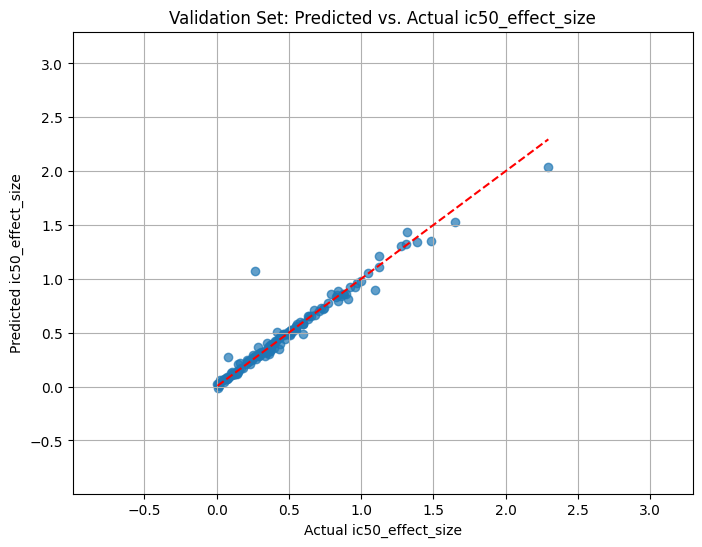

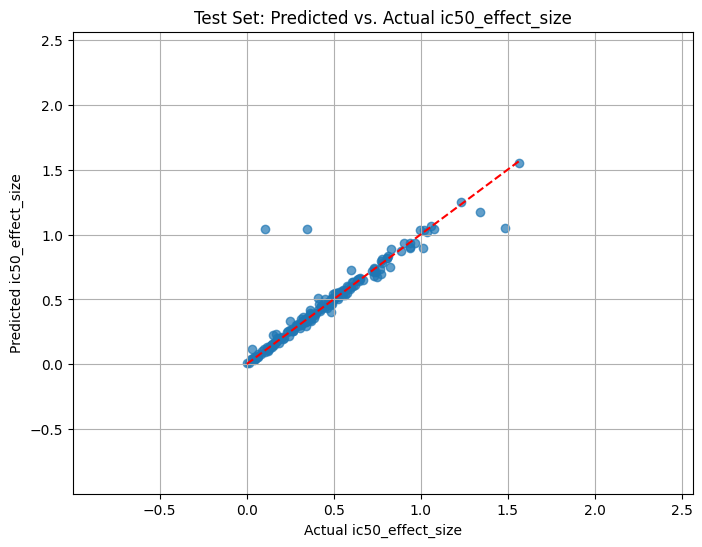

In [ ]:

def plot_predictions(y_actual, y_pred, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_actual, y_pred, alpha=0.7)
    plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], color='red', linestyle='--')
    plt.title(title)
    plt.xlabel('Actual ic50_effect_size')
    plt.ylabel('Predicted ic50_effect_size')
    plt.xlim(y_actual.min() - 1, y_actual.max() + 1)
    plt.ylim(y_actual.min() - 1, y_actual.max() + 1)
    plt.grid()
    plt.show()

# Plot for validation set
plot_predictions(y_val, y_val_pred, 'Validation Set: Predicted vs. Actual ic50_effect_size')

# Plot for test set
plot_predictions(y_test, y_test_pred, 'Test Set: Predicted vs. Actual ic50_effect_size')